<a href="https://colab.research.google.com/github/ikhwanafif05/project-sweat-economy/blob/main/Pickleball_Gentrification_Alpha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- INSTALL DEPENDENCIES (Run once) ---
!pip install overpy

# --- IMPORTS ---
import overpy
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [3]:
# ==========================================
# PART 1: THE NATIONWIDE DATA MINER (STRICT PICKLEBALL ONLY)
# ==========================================

# 1. THE GEOGRAPHY (Nationwide Malaysia)
BBOX = "0.8, 99.6, 7.4, 119.3"
SEARCH_RADIUS_M = 500

class NationwideScanner:
    def __init__(self):
        self.api = overpy.Overpass()
        print(f"[*] Initialized Nationwide Scanner ({BBOX})")

    def _query_with_retry(self, query_str, retries=5):
        for i in range(retries):
            try:
                return self.api.query(query_str)
            except (overpy.exception.OverpassGatewayTimeout, overpy.exception.OverpassTooManyRequests):
                wait_time = (i + 1) * 5
                print(f"[!] Server busy. Retrying in {wait_time}s... (Attempt {i+1}/{retries})")
                time.sleep(wait_time)
            except Exception as e:
                print(f"[!] Error: {e}")
                break
        return None

    def get_pickleball_nodes(self):
        print("[-] Phase 1: Locating Verified Pickleball Courts...")

        # STRICT QUERY: Only finds things explicitly named or tagged "Pickleball"
        query = f"""
        [out:json][timeout:180];
        (
          node["sport"="pickleball"]({BBOX});
          way["sport"="pickleball"]({BBOX});
          node["name"~"Pickleball",i]({BBOX});
          way["name"~"Pickleball",i]({BBOX});
        );
        out center;
        """
        result = self._query_with_retry(query)

        courts = []
        seen_ids = set()

        if result:
            for node in result.nodes + result.ways:
                if node.id in seen_ids: continue
                seen_ids.add(node.id)

                lat = float(node.lat) if hasattr(node, 'lat') else float(node.center_lat)
                lon = float(node.lon) if hasattr(node, 'lon') else float(node.center_lon)
                name = node.tags.get("name", "Unknown Pickleball Court")

                courts.append({
                    "id": node.id,
                    "name": name,
                    "lat": lat,
                    "lon": lon
                })

        print(f"[+] Found {len(courts)} Verified Pickleball Courts.")
        return courts

    def scan_environment_surgical(self, courts):
        print("[-] Phase 2: Performing Surgical Grease Scan...")
        results = []

        # Keywords to identify "Mamak-style" or local high-traffic eateries
        grease_keywords = ['mamak', 'kandar', 'restoran', 'warung', 'kedai', 'bistro', 'corner', 'curry', 'majhu', 'pelita', 'kayu', 'nasi']

        total = len(courts)
        for idx, court in enumerate(courts):
            if idx % 5 == 0: print(f"    Scanning {idx}/{total}: {court['name']}...")

            # Query for all commercial food nodes within walking distance
            amenity_query = f"""
            [out:json][timeout:60];
            (
              node["amenity"="restaurant"](around:{SEARCH_RADIUS_M},{court['lat']},{court['lon']});
              node["amenity"="cafe"](around:{SEARCH_RADIUS_M},{court['lat']},{court['lon']});
              node["amenity"="food_court"](around:{SEARCH_RADIUS_M},{court['lat']},{court['lon']});
              node["cuisine"="mamak"](around:{SEARCH_RADIUS_M},{court['lat']},{court['lon']});
            );
            out qt;
            """

            amenities_result = self._query_with_retry(amenity_query)

            grease_count = 0
            commercial_noise = 0

            if amenities_result:
                for node in amenities_result.nodes:
                    commercial_noise += 1
                    tags = node.tags
                    name = tags.get("name", "").lower()
                    cuisine = tags.get("cuisine", "").lower()

                    is_grease = False
                    if 'mamak' in cuisine or 'malaysian' in cuisine or 'indian' in cuisine:
                        is_grease = True
                    elif any(x in name for x in grease_keywords):
                        is_grease = True

                    if is_grease:
                        grease_count += 1

            # --- THE ALGORITHM (MATCHING THE PITCH DECK) ---
            # Base Score = 98 (The "Prudence Cap" - never assume perfect info)
            # Penalty = Commercial Noise * 2

            base_score = 98
            penalty = commercial_noise * 2
            alpha = max(0, base_score - penalty)

            results.append({
                "Court Name": court['name'],
                "Grease Index (Mamaks)": grease_count,
                "Dead Zone Alpha (0-100)": alpha
            })

            time.sleep(0.1) # Respect API limits

        return pd.DataFrame(results)

# --- EXECUTION ---
scanner = NationwideScanner()
courts = scanner.get_pickleball_nodes()

if courts:
    df = scanner.scan_environment_surgical(courts)
    print("\n[SUCCESS] Strict Data Generated.")
    print(df.sort_values(by="Dead Zone Alpha (0-100)", ascending=False).head(10).to_string(index=False))
else:
    print("[!] No courts found.")

[*] Initialized Nationwide Scanner (0.8, 99.6, 7.4, 119.3)
[-] Phase 1: Locating Verified Pickleball Courts...
[+] Found 20 Verified Pickleball Courts.
[-] Phase 2: Performing Surgical Grease Scan...
    Scanning 0/20: Pickle Social Club...
[!] Server busy. Retrying in 5s... (Attempt 1/5)
[!] Server busy. Retrying in 10s... (Attempt 2/5)
[!] Server busy. Retrying in 5s... (Attempt 1/5)
    Scanning 5/20: Pickle Lah Pickleball Court...
[!] Server busy. Retrying in 5s... (Attempt 1/5)
[!] Server busy. Retrying in 10s... (Attempt 2/5)
[!] Server busy. Retrying in 15s... (Attempt 3/5)
[!] Server busy. Retrying in 20s... (Attempt 4/5)
[!] Server busy. Retrying in 25s... (Attempt 5/5)
[!] Server busy. Retrying in 5s... (Attempt 1/5)
    Scanning 10/20: W Badminton Pickleball Centre...
[!] Server busy. Retrying in 5s... (Attempt 1/5)
[!] Server busy. Retrying in 5s... (Attempt 1/5)
[!] Server busy. Retrying in 5s... (Attempt 1/5)
[!] Server busy. Retrying in 10s... (Attempt 2/5)
    Scanning 

[+] Dark Mode Chart generated: 'pickleball_dark_mode.png'


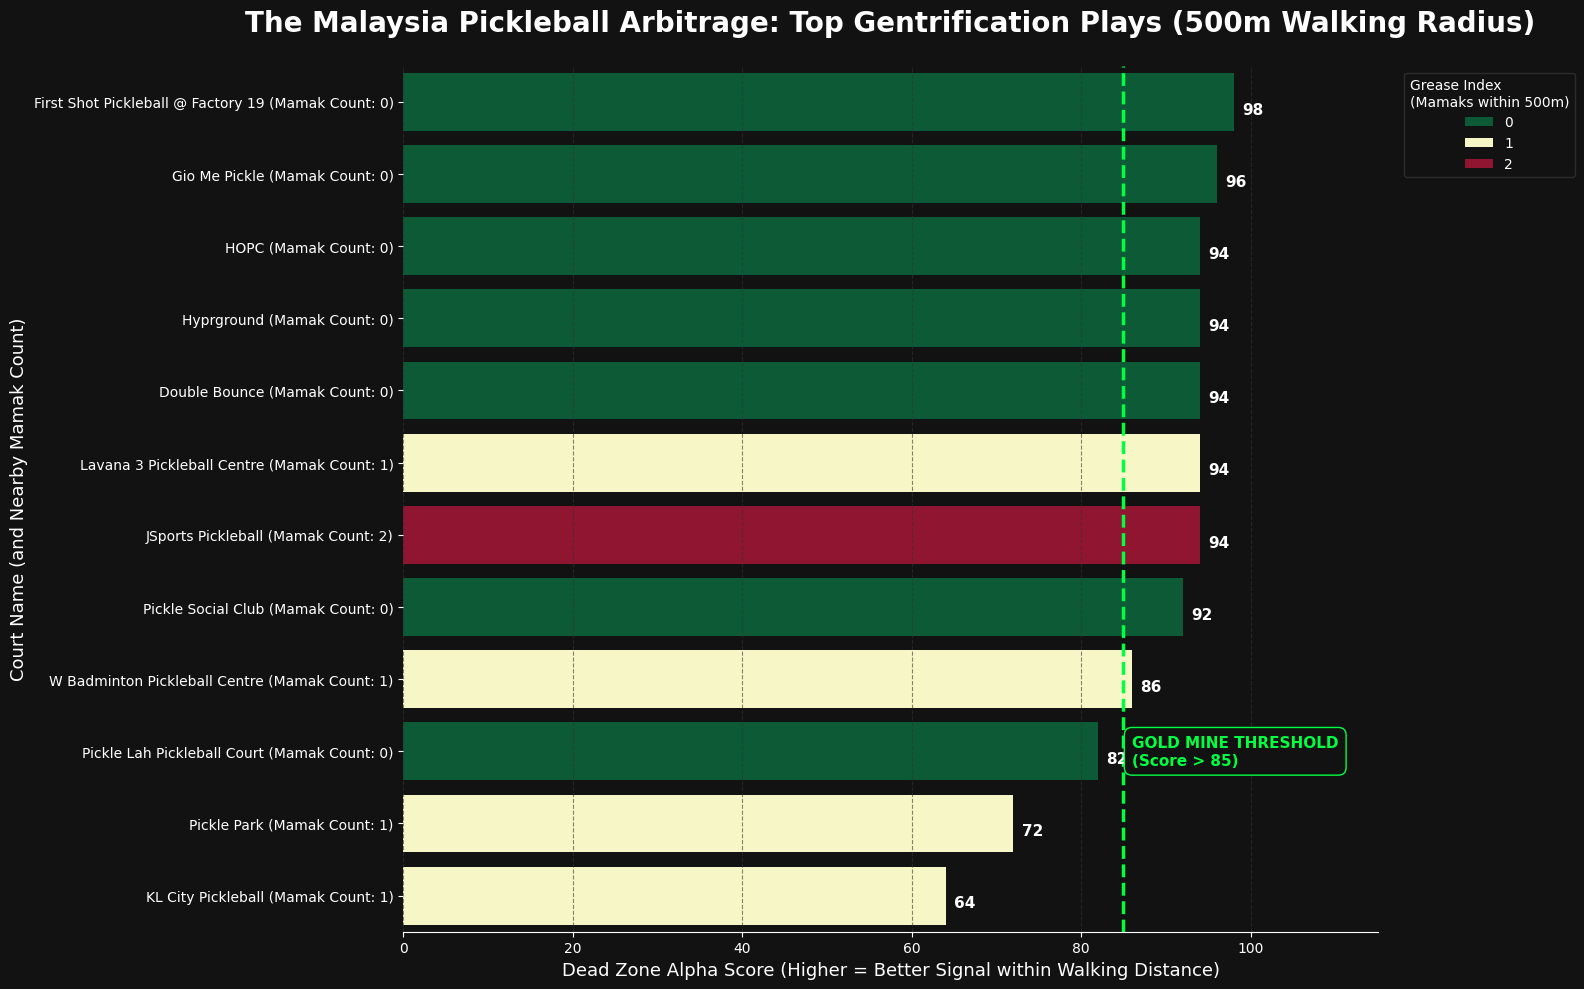

In [4]:
# ==========================================
# PART 2: THE VISUALIZATION (DARK MODE)
# ==========================================

# CHECK: Do we have data?
if 'df' in locals() and not df.empty:

    # --- 0. DARK MODE SETUP ---
    BG_COLOR = "#121212"  # Deep Charcoal
    TEXT_COLOR = "#FFFFFF" # White
    ACCENT_COLOR = "#00FF41" # Terminal Green
    GRID_COLOR = "#333333" # Subtle Grey

    plt.rcParams.update({
        "text.color": TEXT_COLOR,
        "axes.labelcolor": TEXT_COLOR,
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,
        "axes.facecolor": BG_COLOR,
        "figure.facecolor": BG_COLOR,
        "grid.color": GRID_COLOR,
    })

    # 1. CLEAN & SORT
    # FIX: Ensure we filter out the exact string produced by the miner
    clean_df = df[df["Court Name"] != "Unknown Pickleball Court"].drop_duplicates(subset=["Court Name"]).copy()

    # Sort High Alpha -> Low Grease
    viz_df = clean_df.sort_values(
        by=["Dead Zone Alpha (0-100)", "Grease Index (Mamaks)"],
        ascending=[False, True]
    ).head(15).copy().reset_index(drop=True)

    # 2. CREATE LABELS
    viz_df["Label"] = viz_df["Court Name"] + " (Mamak Count: " + viz_df["Grease Index (Mamaks)"].astype(str) + ")"

    # 3. PLOT SETUP
    fig, ax = plt.subplots(figsize=(16, 10))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)

    barplot = sns.barplot(
        data=viz_df,
        x="Dead Zone Alpha (0-100)",
        y="Label",
        hue="Grease Index (Mamaks)",
        palette="RdYlGn_r",
        dodge=False,
        ax=ax
    )

    ax.grid(True, axis='x', color=GRID_COLOR, linestyle='--', alpha=0.6)
    ax.grid(False, axis='y')

    # 4. BAR ANNOTATIONS
    for p in barplot.patches:
        width = p.get_width()
        if width > 0:
            ax.text(
                width + 1,
                p.get_y() + p.get_height() / 2 + 0.1,
                f'{int(width)}',
                ha="left", va="center", fontweight='bold', color=TEXT_COLOR, fontsize=11
            )

    # 5. TARGETING SYSTEM
    plt.axvline(x=85, color=ACCENT_COLOR, linestyle='--', linewidth=2.5)

    # Dynamic Text Placement
    # If we can't find 'Pickle Park', just place it near the threshold line at y=10
    plt.text(
        86,
        len(viz_df) - 3 if len(viz_df) > 3 else 0, # Place near bottom if list is long
        "GOLD MINE THRESHOLD\n(Score > 85)",
        color=ACCENT_COLOR,
        fontweight='bold',
        fontsize=11,
        va='center',
        bbox=dict(facecolor=BG_COLOR, edgecolor=ACCENT_COLOR, boxstyle='round,pad=0.5')
    )

    # 6. TITLES & LABELS
    plt.title("The Malaysia Pickleball Arbitrage: Top Gentrification Plays (500m Walking Radius)",
              fontsize=20, fontweight='bold', pad=25, color=TEXT_COLOR)

    plt.xlabel("Dead Zone Alpha Score (Higher = Better Signal within Walking Distance)", fontsize=13, color=TEXT_COLOR)
    plt.ylabel("Court Name (and Nearby Mamak Count)", fontsize=13, color=TEXT_COLOR)
    plt.xlim(0, 115)

    # 7. LEGEND
    legend = plt.legend(
        title="Grease Index\n(Mamaks within 500m)",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        facecolor=BG_COLOR,
        edgecolor=GRID_COLOR,
        labelcolor=TEXT_COLOR
    )
    plt.setp(legend.get_title(), color=TEXT_COLOR)

    # 8. SAVE & SHOW
    sns.despine(left=True, bottom=False)
    ax.spines['bottom'].set_color(TEXT_COLOR)

    plt.tight_layout()
    plt.savefig("pickleball_dark_mode.png", dpi=300, facecolor=BG_COLOR)
    print("[+] Dark Mode Chart generated: 'pickleball_dark_mode.png'")
    plt.show()

else:
    print("[!] ERROR: No data found. Run Part 1 (Data Miner) first.")

In [5]:
# ==========================================
# PART 3: THE FINAL INVESTMENT MEMO
# ==========================================

if 'df' in locals() and not df.empty:

    # 1. CLEANING & SETUP
    # FIX: Correct string matching for Unknown courts
    final_df = df[df["Court Name"] != "Unknown Pickleball Court"].drop_duplicates(subset=["Court Name"]).copy()

    # ZONING RADAR
    zoning_keywords = ["Golf", "Resort", "Club", "Villa", "Residence", "Hotel", "Suites"]
    final_df["Zoning_Risk"] = final_df["Court Name"].apply(
        lambda x: any(keyword in x for keyword in zoning_keywords)
    )

    # =========================================================
    # CREATE MASKS
    # =========================================================
    gold_mask = (
        (final_df["Dead Zone Alpha (0-100)"] >= 85) &
        (final_df["Grease Index (Mamaks)"] <= 1) &
        (final_df["Zoning_Risk"] == False)
    )

    silver_mask = (
        (final_df["Dead Zone Alpha (0-100)"] >= 85) &
        (final_df["Grease Index (Mamaks)"] > 1) &
        (final_df["Zoning_Risk"] == False)
    )

    avoid_mask = (
        (final_df["Dead Zone Alpha (0-100)"] < 85) |
        (final_df["Zoning_Risk"] == True)
    )

    # Create sorted lists
    gold_list = final_df[gold_mask].sort_values(by="Dead Zone Alpha (0-100)", ascending=False)
    silver_list = final_df[silver_mask].sort_values(by="Dead Zone Alpha (0-100)", ascending=False)
    avoid_list = final_df[avoid_mask].sort_values(by=["Zoning_Risk", "Dead Zone Alpha (0-100)"], ascending=[False, True])

    # =========================================================
    # PRINTING LOGIC
    # =========================================================
    def print_pro_table(dataframe, title):
        if dataframe.empty:
            return

        print(f"\n\n=== {title} ===")
        print(f"{'Court Name':<35} | {'Mamaks':<8} | {'Score':<5} | {'Verdict'}")
        print("-" * 88)

        for _, row in dataframe.iterrows():
            name = row['Court Name'][:33]
            mamaks = row['Grease Index (Mamaks)']
            alpha = row['Dead Zone Alpha (0-100)']
            zoning = row['Zoning_Risk']

            # --- DYNAMIC VERDICT LOGIC ---
            if zoning:
                verdict = "❌ ZONING RISK"
            elif alpha >= 95 and mamaks == 0:
                verdict = "👑 BLUE OCEAN (Perfect)"
            elif alpha >= 85 and mamaks <= 1:
                verdict = "✅ BUY (High Potential)"
            elif alpha >= 85 and mamaks > 1:
                verdict = "⚠️ SATURATED (High Traffic)"
            elif mamaks >= 3:
                verdict = "⚠️ OVERSATURATED (Avoid)"
            elif alpha >= 75:
                verdict = "📉 MODERATE TRAFFIC (Tier 2)"
            else:
                verdict = "💀 LOW SIGNAL / GHOST TOWN"

            print(f"{name:<35} | {mamaks:<8} | {alpha:<5} | {verdict}")

    # EXECUTE
    print_pro_table(gold_list, "TARGET LIST: 'LOCAL MONOPOLIES' (Score > 85, Low Supply)")
    print_pro_table(silver_list, "WATCHLIST: SATURATED ZONES (Score > 85, But Crowded)")
    print_pro_table(avoid_list, "AVOID LIST: ZONING RISKS & LOWER YIELDS")

    print(f"\n[i] Diagnostic: Analyzed {len(final_df)} courts.")

else:
    print("[!] Error: No data found.")



=== TARGET LIST: 'LOCAL MONOPOLIES' (Score > 85, Low Supply) ===
Court Name                          | Mamaks   | Score | Verdict
----------------------------------------------------------------------------------------
First Shot Pickleball @ Factory 1   | 0        | 98    | 👑 BLUE OCEAN (Perfect)
Gio Me Pickle                       | 0        | 96    | 👑 BLUE OCEAN (Perfect)
HOPC                                | 0        | 94    | ✅ BUY (High Potential)
Double Bounce                       | 0        | 94    | ✅ BUY (High Potential)
Hyprground                          | 0        | 94    | ✅ BUY (High Potential)
Lavana 3 Pickleball Centre          | 1        | 94    | ✅ BUY (High Potential)
W Badminton Pickleball Centre       | 1        | 86    | ✅ BUY (High Potential)


=== WATCHLIST: SATURATED ZONES (Score > 85, But Crowded) ===
Court Name                          | Mamaks   | Score | Verdict
----------------------------------------------------------------------------------------
JS